# **Quantum Volunteer's Dilemma Game on NISQ Devices: Experimental Validation, Noise Modeling, and Scalability Analysis**

**Overview**

This notebook presents a comprehensive framework for the implementation and experimental validation of the n-player Volunteer's Dilemma within the quantum game theory paradigm. The model is constructed using the Eisert-Wilkens-Lewenstein (EWL) scheme and executed across three distinct environments: ideal simulation, real quantum hardware (IBM QPU), and a custom Digital Twin constructed from hardware calibration data (T1, T2, gate and readout errors).

The primary objective is to evaluate the scalability of quantum strategies under realistic noise conditions and to quantify the gap between theoretical predictions and experimental outcomes. We explicitly compare these results against the classical Nash equilibrium to assess the persistence of quantum advantage under noise. By systematically varying the number of players and strategy parameters, we analyze both the success probability of the target state and the resulting economic payoffs.

**Reference to Theoretical Framework**

This implementation is based on the theoretical formulation of the Quantum Volunteer's Dilemma presented in:

Koh, D. E., Kumar, K., & Goh, S. T. (2025). Quantum volunteer's dilemma. Physical Review Research, 7(1), 013104.
https://doi.org/10.1103/PhysRevResearch.7.013104

The present work extends this model by providing an experimental validation on NISQ devices, including noise-aware simulations and hardware benchmarking.

While the strategic framework and equilibrium analysis follow the original formulation, this notebook focuses on evaluating their practical viability under realistic quantum noise conditions.

All theoretical benchmarks labeled as “Theorist” throughout this notebook are derived from the analytical results presented in this work.

*Implementation Note: Due to circuit construction constraints, the encoding of the “volunteer” and “non-volunteer” states is inverted at the circuit level. This mapping is consistently corrected during the payoff evaluation stage to preserve alignment with the classical interpretation and the theoretical model.*

**Key Features**

Quantum Circuit Engineering

* Scalable n-qubit EWL circuits for simulation and IBM Quantum hardware

Multi-Environment Execution
Unified workflow supporting:
* Ideal (noise-free) simulation
* Physical QPU execution (IBM Quantum backend)
* Noisy simulation via a calibration-based Digital Twin

Noise Modeling & Digital Twin
Extraction of hardware calibration data (T1, T2, gate errors, readout errors) to construct a realistic noise model using Qiskit Aer.

Statistical & Scaling Analysis
Quantitative evaluation using:
* Linear regression (fidelity decay)
* Coefficient of Variation (CV)
* Confidence intervals (95%, t-Student)
* Hamming distance distribution
* Benchmark error metrics (MAE, RMSE, MRE)
* Kolmogorov–Smirnov test (Digital Twin validation)
* Readout correction impact analysis
* Gate count and circuit depth per optimization level

Benchmarking & Validation
Comparative analysis across:
* Theoretical quantum equilibrium
* Classical Nash equilibrium
* Noisy simulation (Digital Twin)
* Real hardware execution (IBM QPU)

Scalability Study
Systematic exploration from 2 to 9 players to characterize performance degradation, noise scaling, and the persistence of quantum advantage on current NISQ devices.

## **Initialization & Environment Setup**

### **Library Initialization**
This section initializes the computational environment required for the implementation, simulation, and experimental execution of the Quantum Volunteer's Dilemma.

It ensures compatibility with IBM Quantum services, configures the necessary simulation backends, and loads all dependencies for circuit construction, noise modeling, statistical analysis, and visualization.

The setup is designed to support a reproducible workflow across three execution environments: ideal simulation, noisy simulation (Digital Twin), and real quantum hardware.

| Module | Key Functionality |
| :--- | :--- |
| **Quantum (Qiskit)** | Quantum circuit construction, transpilation, and integration with IBM Quantum hardware |
| **Noise Model (Qiskit Aer)** | Simulation of realistic hardware noise (decoherence, gate errors, readout errors) |
|**Qiskit Runtime Utilities**|Reconstruction of IBM job objects and backend configurations from locally stored files, enabling execution without an active cloud connection|
| **Mthree** | Read error correction framework / IBM |
| **Math** | Root finding, regression models, and numerical analysis |
| **Visualization & Interaction** | Plotting, 3D visualization, and interactive parameter exploration |
|**Data & System**|Local storage of experimental results, secure credential input, and filesystem navigation for offline execution|

In [1]:
# Installing external packages (this may take a few seconds)
!pip install -q qiskit==2.4.0 qiskit-ibm-runtime==0.46.1 qiskit_aer pylatexenc mthree --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 

In [2]:
#@title { display-mode: "form" }
#@markdown Click the play button to initialize the environment.

# Quantum Computing Framework
import qiskit
import qiskit_ibm_runtime
import qiskit.version
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import RuntimeDecoder
from qiskit_ibm_runtime.models import BackendProperties
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.models import QasmBackendConfiguration
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)
import mthree # Quantum measurement error mitigation

# Analysis & Math
import numpy as np
import copy
from sklearn.linear_model import LinearRegression
from scipy.optimize import brentq
from scipy import stats
from scipy.stats import ks_2samp
from collections import defaultdict
from scipy.stats import pearsonr
from collections import Counter

# Visualization & Interaction
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Data & System
import json
import pickle
import os
from getpass import getpass

# Environment verification
print(f"✅ Qiskit version: {qiskit.__version__}")
print(f"✅ IBM Runtime version: {qiskit_ibm_runtime.__version__}")

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


✅ Qiskit version: 2.4.0
✅ IBM Runtime version: 0.46.1


All downstream cells depend on the modules initialized above.

### **Quantum Runtime Configuration**

This section establishes the connection to the IBM Quantum Runtime service and configures the execution backend used for experimental validation.

The selected backend defines the physical constraints of the experiment, including qubit connectivity, gate fidelities, coherence times, and readout errors. These factors directly impact the performance of the implemented quantum game.
The configuration follows a two-path authentication model to ensure the notebook remains fully functional regardless of network access. If a live IBM Quantum connection is available, the backend and job objects are retrieved directly from the cloud. If the connection fails or credentials are absent, the system automatically falls back to a local GitHub repository containing the stored experimental results and calibration data, reconstructed using the utility class defined in the following cell.

All hardware-based results reported in this notebook were obtained from the `ibm_kingston` backend (Heron r2 family) and are reproduced through either path.

In [3]:
#@title Connect to Quantum Service { display-mode: "form" }
#@markdown Execute this cell to authenticate and initialize access to the IBM Quantum Runtime service.

# --- CONFIGURATION ---
GITHUB_USER = "GermanDarDiaz"
REPO_NAME = "Quantum-Volunteer-s-Dilemma"
Service_conect = None
# ---------------------

try:
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token="",  # API
        instance="", # Instance
        name="open-instance", #Default
        overwrite=True,
        set_as_default=True
    )

    service = QiskitRuntimeService()
    backend = service.backend("ibm_kingston")

    Service_conect = True

    print(f"✅ Connection Successful")
    print(f"Status: Backend '{backend.name}' selected. Jobs can now be submitted (subject to queue availability).")
except Exception as e:
    print("⚠️ IBM Quantum connection failed or credentials missing. Switching to GitHub storage...")
    service = None

    Service_conect = False

    try:
        # Check if the repository is already cloned to avoid errors
        if not os.path.exists(REPO_NAME):
            # Use getpass to enter the token securely without showing it in the code
            print(f"Please provide your GitHub Personal Access Token (PAT) for {REPO_NAME}")
            git_token = getpass('GitHub Token: ')

            # Clone the private repository
            repo_url = f"https://{git_token}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
            os.system(f"git clone {repo_url}")

        # Change directory to the repository to enable relative paths
        if os.path.exists(REPO_NAME):
            os.chdir(REPO_NAME)
            print(f"✅ GitHub Connection Successful")
            print(f"Current directory: {os.getcwd()}")
            print("Status: Working with local JSON data from 'experiments/' folder.")
        else:
            print("❌ Failed to clone the repository. Check your Token and Username.")

    except Exception as git_error:
        print(f"❌ Critical Error: Could not connect to IBM or GitHub. {git_error}")

⚠️ IBM Quantum connection failed or credentials missing. Switching to GitHub storage...
Please provide your GitHub Personal Access Token (PAT) for Quantum-Volunteer-s-Dilemma
GitHub Token: ··········
✅ GitHub Connection Successful
Current directory: /content/Quantum-Volunteer-s-Dilemma
Status: Working with local JSON data from 'experiments/' folder.


The backend `ibm_kingston` was selected from the set of available IBM Quantum devices at the time of execution, ensuring compatibility with the required circuit size and experimental workflow.

**Data Reconstruction Layer**

This cell defines the infrastructure required for offline execution when a live IBM Quantum connection is unavailable.

Two components are introduced:

`LocalJobMock` is a lightweight wrapper that mimics the interface of a real `IBMRuntimeJob` object. It exposes the `.result()` and `.properties()` methods expected by all downstream cells, allowing the rest of the notebook to operate identically whether data comes from the cloud or from local files. This abstraction insulates the analysis pipeline from the data source, ensuring a consistent interface throughout.

`get_exact_job_object` is the retrieval router. Given a job identifier, it first attempts to fetch the live job from IBM Quantum. If that fails, it loads the corresponding result and properties files from the local repository structure and returns a LocalJobMock instance populated with the stored data. This function is called once in Section 1 and the returned object is reused across all subsequent sections.

In [4]:
#@title Data Reconstruction Layer { display-mode: "form" }
#@markdown MOCK CLASS TO SIMULATE AN IBM JOB OBJECT

class LocalJobMock:
    """The main 'Job' object that mimics IBMRuntimeJob"""
    def __init__(self, results_data, properties_data):
        self._results = results_data
        self._properties = properties_data

    def result(self):
        """Returns the PrimitiveResult (Sampler V2)"""
        return self._results

    def properties(self):
        """Replicates: job.properties()"""
        #return BackendPropertiesMock(self._info)
        return self._properties

    def __getitem__(self, key):
        """
        Allows access like job[optimization_level] if your code
        expects the job object to be subscriptable.
        """
        return self

# --- UPDATED RETRIEVAL FUNCTION ---

def get_exact_job_object(exp_id, jobs_dict, service):
    """
    Retrieves either a live IBM Job or reconstructs one
    matching your specific JSON file structure.
    """
    # Assuming jobs_dict maps "1" -> "d5sq211fodos73ekbkkg"
    job_id = jobs_dict[exp_id]

    if service:
        try:
            return service.job(job_id)
        except:
            print("⚠️ Cloud connection unavailable. Reconstructing from GitHub...")

    # Load from local Git structure
    res_path = f"experiments/run_0{exp_id + 1}/measurement_results.json"
    properties_path = f"experiments/run_0{exp_id + 1}/properties.json"

    try:
        with open(res_path, 'r') as f:
            # Reconstructs the 'PrimitiveResult' object
            res_obj = json.load(f, cls=RuntimeDecoder)

        with open(properties_path, 'r') as f:
            data = json.load(f)
            properties_obj = BackendProperties.from_dict(data)

        print(f"✅ Reconstructed Job {job_id} correctly.")

        return LocalJobMock(res_obj, properties_obj)
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

## **1. Game Definition & Execution Parameters**
This section defines the theoretical and operational parameters of the Quantum Volunteer's Dilemma.

It includes the economic structure of the game (benefits and costs), the analytical computation of the classical Nash equilibrium, and the configuration of the quantum strategy space through parametrized unitary operators.

These parameters establish the baseline for both theoretical predictions and experimental evaluation.

*Note : All parameters, payoff formulas, and equilibrium expressions used in this section are derived directly from the theoretical framework established in the reference paper (Koh, Kumar & Goh, 2025). For full derivations and proofs, the reader is referred to that work. Values computed here serve exclusively as numerical inputs for the simulation and experimental pipeline.*

In [5]:
# Reproducibility Seed
SEED = 42

# 1. NumPy (affects parameter sweeps, random sampling, etc.)
np.random.seed(SEED)

# Classical symmetric Nash equilibrium probability p*(N)
# Solved numerically (no closed-form for general N)
def p_star(N):
    f = lambda p: ((1 - p)**(N - 1)) * (2 * N * p + 1 - p) - 1
    return brentq(f, 0.0001, 0.9999)

# Payoff parameters: b (benefit), c (cost), with b > c (dilemma condition)
b = 2
c = 1

# Player range for scalability analysis
Num_Players = 2
T_Players = 9

# Number of circuit executions
Shots = 2048
Num_Parts = 10
N_reps = 20

# Quantum strategy space
Theta = 0
Phi = np.pi/Num_Players

# Parameter sweeps for full strategy exploration
Thetas = np.linspace(0, np.pi, (2*(Num_Parts//2))+1)
Phis = np.linspace(0, 2*np.pi, (2*Num_Parts)+1)

# List of players
players = [i for i in range(2, T_Players + 1)]

# Theoretical quantum payoff
Theorist = [1.5, 1.67, 1.75, 1.8, 1.83, 1.86, 1.88, 1.89]

# Classical payoff using Nash equilibrium p*(N)
Classical = [(b - c/i) * (1 - (1 - p_star(i))**i) for i in range(2, T_Players + 1)]

# Mapping the qubits and retrieving data from specific IBM Quantum runs
Qubits = [i for i in range(T_Players)]
list_par_qubits = [(i, i+1) for i in range(T_Players)]
list_q = Qubits + list_par_qubits

# Active optimization level for this analysis run (0–3)
optimization_level = 2

# Retrieve stored IBM Quantum jobs (avoids re-running hardware experiments)
Jobs = {0 : 'd7p70cedvl0c738olqbg', 1 : 'd7p7318ror3c73c0q8c0', 2 : 'd7p75nr9ak2c739rcuqg', 3 : 'd7p77nr9ak2c739rd1b0'}

if Service_conect:
    Job = service.job(Jobs[optimization_level])
    config = backend.configuration()
else:
    Job = get_exact_job_object(optimization_level, Jobs, service)

    backend_path = f"experiments/run_0{optimization_level + 1}/backend.pkl"

    with open(backend_path, 'rb') as f:
        loaded_target = pickle.load(f)

    # Backend Reconstruction
    backend = GenericBackendV2(num_qubits=loaded_target.num_qubits)
    setattr(backend, "_target", loaded_target)

    with open(f'experiments/run_0{optimization_level + 1}/backend_configuration.json', 'r') as f:
        data = json.load(f)

    config = QasmBackendConfiguration.from_dict(data)


print("✅ Game parameters and Job history initialized.")

✅ Reconstructed Job d7p75nr9ak2c739rcuqg correctly.
✅ Game parameters and Job history initialized.


## **2. Quantum Volunteer's Dilemma Framework**
This section implements the quantum version of the Volunteer's Dilemma using the Eisert–Wilkens–Lewenstein (EWL) framework.

The protocol consists of three stages: (1) an entangling operator that correlates all players, (2) parametrized strategy operators $U(θ,ϕ)$, and (3) the inverse entangling operation $J^{†}$
, which maps the state back to the computational basis for measurement.

The resulting bitstrings are then used to compute expected payoffs according to the economic rules of the game.

In [6]:
class QuantumVolunteersdilemma:
    # Initialize n-player quantum game (n qubits + n classical bits)
    def __init__(self, n):
        self.n = n
        self.q = [i for i in range(n)]
        self.qc = QuantumCircuit(n, n)

    # EWL entangling operator: creates correlated initial state
    def entangled(self):
        self.qc.sdg(self.q)
        self.qc.h(self.q)
        self.qc.barrier()
        for i in range((self.n)-1):
            self.qc.cx(i, i+1)
        self.qc.rz(np.pi/2, (self.n)-1)
        for i in range((self.n)-1, 0, -1):
            self.qc.cx(i-1, i)
        self.qc.barrier()
        self.qc.h(self.q)
        self.qc.s(self.q)

    # Apply player strategies via parametrized unitary U(θ, φ)
    # Decomposed into native Qiskit gates as: Rz(-π-φ) · Ry(θ) · Rz(π-φ)
    # Shared=True → all players use identical (θ, φ); symmetric strategy configuration.
    def Strategy(self, Theta, Phi, Shared=True):
        if Shared:
            self.qc.rz(-(np.pi)-(Phi), self.q)
            self.qc.ry(Theta, self.q)
            self.qc.rz((np.pi)-(Phi), self.q)
        else:
            for i in range(self.n):
                self.qc.rz(-(np.pi)-(Phi[i]), i)
                self.qc.ry(Theta[i], i)
                self.qc.rz((np.pi)-(Phi[i]), i)

    # EWL uncompute: disentangles state before measurement
    def entangled_dag(self):
        self.qc.sdg(self.q)
        self.qc.h(self.q)
        self.qc.barrier()
        for i in range((self.n)-1):
            self.qc.cx(i, i+1)
        self.qc.rz((3*np.pi)/2, (self.n)-1)
        for i in range((self.n)-1, 0, -1):
            self.qc.cx(i-1, i)
        self.qc.barrier()
        self.qc.h(self.q)
        self.qc.s(self.q)

    # Visualize quantum circuit
    def DrawQC(self):
        return self.qc.draw()

    # Get full quantum state (ideal, pre-measurement)
    def StateVectorQC(self):
        return Statevector(self.qc)

    # Execute circuit (Aer simulator) and return measurement counts
    def Execute(self, shot):
        self.shot=shot
        self.qc.barrier()
        self.qc.x(self.q) # Final X gate flips encoding (aligns with classical interpretation)
        self.qc.measure(self.q, self.q)
        Aer = AerSimulator(seed_simulator=SEED)
        Run = Aer.run(self.qc, shots=self.shot)
        self.Results = Run.result().get_counts()
        return self.Results

    # Compute expected payoffs from measurement outcomes
    def Payoff(self, b, c):
        Values = {}
        Pays = {}
        Wt = 0
        # Count number of volunteers (Wt) per outcome
        for key in self.Results.keys():
            Probability = self.Results[key]/self.shot
            for i in range(self.n):
                if key[i] == '1':
                    Wt = Wt + 1
            if Wt == 0:
                Values[key] = [Probability] + [0 for i in range(self.n)]
            else:
                pay = []
                for i in range(self.n, 0, -1):
                    if key[i-1] == '1':
                        pay.append(b - (c / Wt))
                    else:
                        pay.append(b)
                Values[key] = [Probability] + pay
            Wt = 0
        Suport = [0 for i in range(self.n)]
        for key in Values.keys():
            for j in range(self.n):
                Suport[j] = Suport[j] + (Values[key][j+1]*Values[key][0])
        for i in range(self.n):
            Pays[f'J{i+1}'] = Suport[i]
        return Pays, Values

This class builds the full EWL circuit in a single pass for execution on quantum hardware.

It returns a complete QuantumCircuit ready for transpilation, combining entanglement, strategy application, and disentanglement into a single construction flow.

In [7]:
class QuantumVolunteersdilemma_Real:
    # Initialize circuit for hardware execution
    def __init__(self, n):
        self.n = n
        self.q = [i for i in range(n)]
        self.qc = QuantumCircuit(n, n)

    # Build full EWL circuit in a single pass
    def Build(self, Theta, Phi, Shared=True):
        """
        Constructs the complete quantum circuit in one pass.
        Returns: A Qiskit QuantumCircuit object.
        """
        # --- Phase 1: Entanglement ---
        self.qc.sdg(self.q)
        self.qc.h(self.q)
        self.qc.barrier()
        for i in range((self.n)-1):
            self.qc.cx(i, i+1)
        self.qc.rz(np.pi/2, (self.n)-1)
        for i in range((self.n)-1, 0, -1):
            self.qc.cx(i-1, i)
        self.qc.barrier()
        self.qc.h(self.q)
        self.qc.s(self.q)

        # --- Phase 2: Strategy Application U(θ, φ) ---
        if Shared:
            self.qc.rz(-(np.pi)-(Phi), self.q)
            self.qc.ry(Theta, self.q)
            self.qc.rz((np.pi)-(Phi), self.q)
        else:
            for i in range(self.n):
                self.qc.rz(-(np.pi)-(Phi[i]), i)
                self.qc.ry(Theta[i], i)
                self.qc.rz((np.pi)-(Phi[i]), i)

        # --- Phase 3: Disentanglement (uncompute) ---
        self.qc.sdg(self.q)
        self.qc.h(self.q)
        self.qc.barrier()
        for i in range((self.n)-1):
            self.qc.cx(i, i+1)
        self.qc.rz((3*np.pi)/2, (self.n)-1)
        for i in range((self.n)-1, 0, -1):
            self.qc.cx(i-1, i)
        self.qc.barrier()
        self.qc.h(self.q)
        self.qc.s(self.q)

        # --- Phase 4: Measurement preparation ---
        self.qc.barrier()
        self.qc.x(self.q)
        self.qc.measure(self.q, self.q)
        return self.qc

### **Functions**

This section defines two utility functions used in Sections 3 and 4:
`pi_formatter` formats axis ticks as multiples of π for angular parameter plots,
and `plot_function` renders the payoff landscape from precomputed simulation data
for a given (N, θ) configuration.

In [8]:
# Format axis ticks as multiples of π (physical notation)
def pi_formatter(x, pos):
    """
    Utility: Formats numerical values into LaTeX-style Pi fractions for the plots.
    """
    frac = x / np.pi
    if np.isclose(frac, 0): return "0"
    elif np.isclose(frac, 1): return "π"
    elif frac.is_integer(): return f"{int(frac)}π"
    else: return f"{frac:.2f}π"

# Plot expected payoffs from precomputed simulation data (Results_S)
def plot_function(Players=9, thet=3):
    """
    Core Plotting Engine: Retrieves results from the simulation dictionary
    and generates a multi-player payoff chart.
    """
    clear_output(wait=True)

    # Store payoff curves for each player
    J = [[] for i in range(Players)]

    # Extract payoffs from global simulation dictionary
    for i in range(Players):
        for phi in Phis:
            J[i].append(Results_S[f'{Players},{Thetas[thet]},{phi}'][0][f'J{i+1}'])

    # Plot payoff vs φ for each player
    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(Players):
        ax.plot(Phis, J[i], marker='o', label=f'Player {i+1}', alpha=0.7)

    # Configure labels and layout
    ax.set_title(f'Payoffs for {Players} players and θ : {Thetas[thet]}')
    ax.set_xlabel('ϕ')
    ax.set_ylabel('Payoff')

    # Move legend outside for clarity
    ax.legend(
      loc='upper left',
      bbox_to_anchor=(1.01, 1.0), # Coordinates (X, Y)
      ncol=1,                     # Number of columns in the legend
      fancybox=True,
      shadow=True
    )
    ax = plt.gca()

    # Format x-axis in multiples of π
    ax.xaxis.set_major_locator(MultipleLocator(np.pi / 4))
    ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
    plt.grid(True)
    plt.show()

**Interactive Explorer**
Adjust the sliders to update the payoff visualization in real time.

* Players: Number of players in the game
* Theta: Index of the selected $\theta$ value in the parameter sweep

In [9]:
# Interactive controls for player count and θ selection
S_Num_Players = widgets.IntSlider(
    value=2,
    min=2,
    max=T_Players,
    step=1,
    description='Players:',
    continuous_update=False
)

# Interactive dashboard linking sliders to plotting function
S_Theta = widgets.IntSlider(
    value=0,
    min=0,
    max=(2*(Num_Parts//2)),
    step=1,
    description='Position Theta:',
    continuous_update=False
)

Interface = widgets.interactive(
    plot_function,
    Players=S_Num_Players,
    thet=S_Theta
)

**Economic Evaluation Engine**

This function converts quantum measurement results into expected payoffs.

For each outcome (bitstring), it counts the number of volunteers (state '1') and applies the cost-sharing rule of the Volunteer's Dilemma.

The final payoff for each player is computed as the probability-weighted average over all outcomes.

This function can be used with both simulated and real hardware results.

In [10]:
# Compute expected payoffs from measurement results (hardware or simulation)
def Payoff(n, Results, shot, B, C):
    """
    Calculates the expected utility for each player.

    Args:
        n (int): Number of players.
        Results (dict): Measurement counts from the quantum execution.
        shot (int): Total number of executions.
        B (float): Benefit of the public good.
        C (float): Cost of volunteering.
    """
    Values = {}
    Pays = {}
    Wt = 0  # Count number of volunteers ('1') per outcome

    for key in Results.keys():
      Probability = Results[key]/shot
      for i in range(n):
        if key[i] == '1':
          Wt = Wt + 1

      # Compute expected value (probability-weighted payoff)
      if Wt == 0:
        # If no one volunteers, everyone gets 0
        Values[key] = [Probability] + [0 for i in range(n)]
      else:
        pay = []
        # Qiskit returns bitstrings in little-endian order:
        # For 2 players, '01' means: key[0]='0' → qubit 1 (Player 2, did not volunteer)
        #                             key[1]='1' → qubit 0 (Player 1, volunteered)
        # We iterate right-to-left (range(n, 0, -1)) to match qubit → player mapping.
        for i in range(n, 0, -1):
          if key[i-1] == '1':
            pay.append(B - (C / Wt))  # Volunteers share the cost
          else:
            pay.append(B) # Free-riders get the benefit for free
        Values[key] = [Probability] + pay

      Wt = 0  # Reset for the next outcome

    # Step 3: Compute probability-weighted expected payoff for each player
    Support = [0 for i in range(n)]
    for key in Values.keys():
      for j in range(n):
        # Probability * Payoff for each player
        Support[j] = Support[j] + (Values[key][j+1]*Values[key][0])

    # Format the results into a readable dictionary
    for i in range(n):
      Pays[f'J{i+1}'] = Support[i]

    return Pays, Values

## **3. Quantum Circuit Construction & Execution**
This section follows the full execution flow of the quantum game, from circuit construction to payoff evaluation.

The procedure implements the EWL protocol step by step:

1. **Initialize**: Define the N-player quantum system.
2. **Entangle:** Apply the entangling operator to create correlations.
3. **Strategy:** Apply the parametrized operators $U(θ,ϕ)$.
4. **Disentangle:** Apply J† to map the state to the measurement basis.
5. **Analyze:** Inspect the statevector and execute the circuit.
6. **Payoff:** Compute expected economic outcomes from measurement results.

In [11]:
# 1. Create the Quantum Volunteer's Dilemma object
# Here we use the 'Num_Players' defined in the parameters section
QVD = QuantumVolunteersdilemma(Num_Players)

# 2. Entanglement Phase
QVD.entangled()

# 3. Apply Player Strategies
# Apply strategy operator U(θ, φ)
# If Shared=True, all players use the same strategy
QVD.Strategy(Theta, Phi, Shared=True)

# 4. Disentanglement Phase (Uncomputing)
QVD.entangled_dag()

# --- Diagnostics ---

# View the State Vector before measurement
print("--- State Vector ---")
display(QVD.StateVectorQC())

# Draw the resulting Quantum Circuit
print("\n--- Circuit Diagram ---")
display(QVD.DrawQC())

# 5. Run the Simulation
# We execute the circuit 'Shots' times to get statistical data
Result = QVD.Execute(Shots)
print(f"\n✅ Simulation Results ({Shots} shots):")
print(Result)

# 6. Calculate Payoffs
# b = benefit, c = cost
payments, values = QVD.Payoff(b, c)

print("\n--- Final Economic Outcomes ---")
print("Expected Payout per Player:", payments)
print("\nDetailed Scenario Analysis:")
print("Format: { 'State': [Probability, Payoff Player 1, Payoff Player 2, ...] }")
display(values)

--- State Vector ---
Statevector([ 1.00000000e+00+0.00000000e+00j,
             -2.43743209e-33-1.34692639e-17j,
              0.00000000e+00-8.90187929e-18j,
              3.45159781e-34-1.66533454e-16j],
            dims=(2, 2))

--- Circuit Diagram ---


┌─────┐┌───┐ ░                       ░ ┌───┐┌───┐┌───────────┐┌───────┐»
q_0: ┤ Sdg ├┤ H ├─░───■───────────────■───░─┤ H ├┤ S ├┤ Rz(-3π/2) ├┤ Ry(0) ├»
     ├─────┤├───┤ ░ ┌─┴─┐┌─────────┐┌─┴─┐ ░ ├───┤├───┤├───────────┤├───────┤»
q_1: ┤ Sdg ├┤ H ├─░─┤ X ├┤ Rz(π/2) ├┤ X ├─░─┤ H ├┤ S ├┤ Rz(-3π/2) ├┤ Ry(0) ├»
     └─────┘└───┘ ░ └───┘└─────────┘└───┘ ░ └───┘└───┘└───────────┘└───────┘»
c: 2/═══════════════════════════════════════════════════════════════════════»
                                                                            »
«     ┌─────────┐┌─────┐┌───┐ ░                        ░ ┌───┐┌───┐
«q_0: ┤ Rz(π/2) ├┤ Sdg ├┤ H ├─░───■────────────────■───░─┤ H ├┤ S ├
«     ├─────────┤├─────┤├───┤ ░ ┌─┴─┐┌──────────┐┌─┴─┐ ░ ├───┤├───┤
«q_1: ┤ Rz(π/2) ├┤ Sdg ├┤ H ├─░─┤ X ├┤ Rz(3π/2) ├┤ X ├─░─┤ H ├┤ S ├
«     └─────────┘└─────┘└───┘ ░ └───┘└──────────┘└───┘ ░ └───┘└───┘
«c: 2/═════════════════════════════════════════════════════════════
«


✅ Simulation Results (2048 shots):
{'11': 2048}

--- Final Economic Outcomes ---
Expected Payout per Player: {'J1': 1.5, 'J2': 1.5}

Detailed Scenario Analysis:
Format: { 'State': [Probability, Payoff Player 1, Payoff Player 2, ...] }


{'11': [1.0, 1.5, 1.5]}

## **4. Ideal Simulation Mapping**
This section generates the baseline dataset by simulating the quantum game under ideal (noise-free) conditions.

A full parameter sweep is performed over:

* the number of players $N$
* the strategy parameter $θ$
* the strategy parameter $ϕ$

The resolution of the parameter space is controlled by `Num_Parts`, which defines the number of discretization points used for $θ$ and $ϕ$.

For each configuration, the circuit is constructed, executed, and evaluated to compute the corresponding payoffs.

All results are stored in a global dictionary `Results_S`, indexed by $(N,θ,ϕ)$, enabling efficient retrieval for visualization and analysis without re-running simulations.

This step is computationally intensive but performed only once.

In [12]:
#@title Run Global Simulation Mapping { display-mode: "form" }
#@markdown This may take a minute depending on the number of players and resolution (Num_Parts).

Results_S = {}

print("🚀 Starting global simulation mapping...")

# Triple loop: for each (N players, θ, φ) configuration,
# we build, run, and store the result. Total scenarios = (T_Players-1) × |Thetas| × |Phis|
# This is the most compute-intensive step; run once and cache Results_S.
for i in range(2, T_Players+1):
    print(f"Processing games for {i} players...")
    for T in Thetas:
        for P in Phis:
            # 1. Initialize and build the circuit for each configuration
            Dilemma = QuantumVolunteersdilemma(i)
            Dilemma.entangled()
            Dilemma.Strategy(T, P)
            Dilemma.entangled_dag()

            # 2. Execute simulation
            Dilemma.Execute(Shots)

            # 3. Calculate and store results
            # We use a unique string key: 'players,theta,phi'
            Pages, Values = Dilemma.Payoff(b, c)
            Results_S[f'{i},{float(T)},{float(P)}'] = [Pages, Values] #players, theta, phi

print("\n✅ Simulation Mapping Complete!")
print(f"Total scenarios calculated: {len(Results_S)}")

🚀 Starting global simulation mapping...
Processing games for 2 players...
Processing games for 3 players...
Processing games for 4 players...
Processing games for 5 players...
Processing games for 6 players...
Processing games for 7 players...
Processing games for 8 players...
Processing games for 9 players...

✅ Simulation Mapping Complete!
Total scenarios calculated: 1848


**Explore the Simulated Landscape**

Use the interactive dashboard to visualize payoffs for selected $(N,θ)$ configurations across the $ϕ$ range.

In [13]:
# Note: display(Interface) is commented out to avoid GitHub rendering issues with interactive widgets.
#display(Interface)

## **5. Real Quantum Hardware Execution**
This section transitions from ideal simulation to physical execution on an IBM Quantum Processing Unit (QPU).

Circuits are executed using the *Sampler* primitive, while a *preset PassManager* adapts them to the topology and constraints of the selected backend.

The collected data serves as the basis for subsequent noise modeling and statistical analysis, enabling direct comparison between theoretical predictions and experimental outcomes.

*Note: The following cell contains the hardware submission code enclosed in triple quotes ("""), which renders it inactive. It is included for transparency and reproducibility documentation only, it will not execute when running the notebook. To reactivate it, remove the surrounding triple quotes and ensure your IBM Quantum credentials are properly configured.*

In [14]:
# ==============================================================================
# ⚠️ REAL HARDWARE EXECUTION CONTROL
# ==============================================================================
# This block is disabled by default to prevent unintended use of QPU resources.
#
# To enable execution on real hardware:
#   1. Ensure access to IBM Quantum Runtime is properly configured.
#   2. Uncomment the code below.
#   3. Verify that 'backend' and 'Shots' are correctly defined.
# ==============================================================================

"""
# 1. Initialize the Sampler
sampler = Sampler(backend)

# 2. Transpilation & Layout Mapping
qc = []
print(f"🛠️ Preparing circuits for {backend.name} (Optimization Level: {optimization_level})...")

for N in range(2, T_Players + 1):
    for j in range(N_reps):
        Layout = [i for i in range(N)]
        QC = QuantumVolunteersdilemma_Real(N).Build(0, np.pi/N, Shared=True)
        qc.append(copy.deepcopy(generate_preset_pass_manager(backend=backend, optimization_level=optimization_level, initial_layout=Layout).run(QC)))

# 3. Job Submission
print(f"🚀 Sending job to IBM Quantum Cloud...")
job = sampler.run(qc, shots=Shots)
print(f"✅ Job ID: {job.job_id()}")

# 4. Data Retrieval (This step waits for the QPU to finish)
result = job.result()
print("📊 Hardware execution complete. Data retrieved.")
"""

'\n# 1. Initialize the Sampler\nsampler = Sampler(backend)\n\n# 2. Transpilation & Layout Mapping\nqc = []\nprint(f"🛠️ Preparing circuits for {backend.name} (Optimization Level: {optimization_level})...")\n\nfor N in range(2, T_Players + 1):\n    for j in range(N_reps):\n        Layout = [i for i in range(N)]\n        QC = QuantumVolunteersdilemma_Real(N).Build(0, np.pi/N, Shared=True)\n        qc.append(copy.deepcopy(generate_preset_pass_manager(backend=backend, optimization_level=optimization_level, initial_layout=Layout).run(QC)))\n\n# 3. Job Submission\nprint(f"🚀 Sending job to IBM Quantum Cloud...")\njob = sampler.run(qc, shots=Shots)\nprint(f"✅ Job ID: {job.job_id()}")\n\n# 4. Data Retrieval (This step waits for the QPU to finish)\nresult = job.result()\nprint("📊 Hardware execution complete. Data retrieved.")\n'

## **6. Noise Modeling from Hardware Data & Statistical Preprocessing**

This section constructs a calibration-based noise model from the hardware
job properties and runs the Digital Twin simulation. It then processes the
raw QPU results to extract statistical metrics for all player counts.

### **6.1. Calibration-Based Noise Modeling & Digital Twin Simulation**

Builds a calibration-driven noise model and performs noisy simulations to replicate hardware behavior.

In [15]:
# --- 1. Extract Hardware Properties ---
# Hardware calibration data is extracted directly from the job's stored properties.
# T1: qubit relaxation time
# T2: qubit dephasing time (T2 ≤ 2·T1)

T1, T2, gate_times, gate_errors, readout_probs = {}, {}, {}, {}, {}

list_qubits = [(i,) for i in range(T_Players)]
list_par_qubits = [(i, i+1) for i in range(T_Players - 1)]
list_q = list_qubits + list_par_qubits

mit = mthree.M3Mitigation()
cal_matrices = []

print(f"📡 Extracting calibration data from: {config.backend_name}")

for i in range(T_Players):
    qubit_props = Job.properties().qubit_property(i)

    # Access specific properties
    t1 = qubit_props.get("T1", (None,))[0]
    t2 = qubit_props.get("T2", (None,))[0]
    readout_error = qubit_props.get("readout_error", (None,))[0]
    prob_meas0_prep1 = qubit_props.get("prob_meas0_prep1", (None,))[0]
    prob_meas1_prep0 = qubit_props.get("prob_meas1_prep0", (None,))[0]
    readout_length = qubit_props.get("readout_length", (None,))[0]

    cal_matrices.append(np.array([
        [1 - prob_meas0_prep1, prob_meas1_prep0],
        [prob_meas0_prep1,     1 - prob_meas1_prep0]
    ]))

    for instruction in config.supported_instructions:
        if instruction == 'cz' or instruction == 'ecr':
            try:
                cz1 = Job.properties().gate_error(instruction, (i, i-1))
            except:
                pass

            try:
                cz2 = Job.properties().gate_error(instruction, (i, i+1))
                if i != 8:
                    gate_errors[(instruction, (i, i+1))] = cz2
            except:
                pass
        else:
            try:
                inst = Job.properties().gate_error(instruction, (i))
                gate_errors[(instruction, i)] = inst
            except:
                pass

    T1[i], T2[i] = t1, t2
    readout_probs[i] = {"P01": prob_meas0_prep1, "P10": prob_meas1_prep0}

    for gate in Job.properties().gates:
        # Convert gate.qubits to a tuple to make it hashable
        qubits_tuple = tuple(gate.qubits)
        if tuple(gate.qubits) in list_q:
            try:
                if gate.gate == 'cz' or gate.gate == 'ecr':
                    gate_times[(gate.gate, qubits_tuple)] = gate.parameters[1].value
                else:
                    gate_times[(gate.gate, qubits_tuple[0])] = gate.parameters[1].value
            except:
                pass

# --- 2. Construct Noise Model ---
noise_model = NoiseModel()

used_qubits = [i for i in range(T_Players)]

# Single Qubit Gates (Thermal + Depolarizing)
for q in Qubits:
    T1_q = T1[q]
    T2_q = T2[q]
    for gate in ['sx', 'x', 'id']:
        if (gate, q) in gate_errors:
            p_gate = gate_errors[(gate, q)]
            t_gate = gate_times[(gate, q)] * 1e-9

            thermal = thermal_relaxation_error(T1_q, T2_q, t_gate)
            depol = depolarizing_error(p_gate, 1)

            total_error = depol.compose(thermal)

            noise_model.add_quantum_error(total_error, gate, [q])

# Two-Qubit Gates (ECR: thermal relaxation per qubit + correlated ZZ Pauli error)
for (gate, pair), p_gate in gate_errors.items():
    if gate in ("cz", "ecr"):
        q0, q1 = pair

        t_gate = gate_times[(gate, pair)] * 1e-9

        thermal_q0 = thermal_relaxation_error(T1[q0], T2[q0], t_gate)
        thermal_q1 = thermal_relaxation_error(T1[q1], T2[q1], t_gate)

        thermal_2q = thermal_q0.tensor(thermal_q1)
        pauli_2q = pauli_error([("ZZ", p_gate), ("II", 1 - p_gate)])

        total_error = pauli_2q.compose(thermal_2q)

        noise_model.add_quantum_error(total_error, gate, [q0, q1])

# Readout Errors
for q in used_qubits:
    P01 = readout_probs[q]["P01"]
    P10 = readout_probs[q]["P10"]

    readout = ReadoutError([[1 - P10, P10], [P01, 1 - P01]])

    noise_model.add_readout_error(readout, [q])

# --- 3. Execute Noisy Simulation ---

print("🚀 Running noisy simulation (Digital Twin)...")

c_state = '1'
R_sim, val_sim = [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)]

# 20 independent seeds serve two purposes:
# (1) match the QPU sample size for the KS test comparison
# (2) verify model stability — low variance across seeds indicates
#     that stochastic shot noise is small relative to systematic noise
DT_SEEDS = list(range(N_reps))

for N in range(2, (T_Players+1)):
    c_state = c_state + '1'
    list_qu = [i for i in range(N)]
    for j in range(N_reps):
        sim = AerSimulator(noise_model=noise_model, seed_simulator=DT_SEEDS[j])
        QSR = QuantumVolunteersdilemma_Real(N).Build(0, np.pi/N)
        QSR_t = generate_preset_pass_manager(backend=backend, optimization_level=optimization_level, initial_layout=list_qu).run(QSR)
        Run = sim.run(QSR_t, shots=Shots)
        Results = Run.result().get_counts()
        R_sim[N-2].append(Results[c_state]/Shots)
        p_sim, _ = Payoff(N, Results, Shots, b, c)
        val_sim[N-2].append(np.mean(list(p_sim.values())))

print("✅ Noisy Simulation Complete. Results stored in R_sim.")

📡 Extracting calibration data from: ibm_kingston
🚀 Running noisy simulation (Digital Twin)...
✅ Noisy Simulation Complete. Results stored in R_sim.


### **6.2. Statistical Processing of Hardware Data**

Processes raw QPU results to compute expected payoffs, variances, noise-related metrics and others.

In [16]:
# Retrieve result from the previously executed Job
result = Job.result()

# Data containers indexed by player count (index i → N = i+2)
val, prob, pay_1 = [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)]
Var_mues, Des_mues, Des_state_1, Des_err, Noise = [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)]
val_mit, prob_mit, pay_1_mit = [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)]
Var_mues_mit, Des_mues_mit, Des_state_1_mit, Des_err_mit, Noise_mit = [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)], [[] for i in range(T_Players - 1)]
aggregated_counts = {}

state = '1'
support, support2, support3, support4, support5, support6, Count, Count2 = 0, 0, 0, 0, 0, 0, 0, 0

print(f"📊 Analyzing statistics for Optimization Level: {optimization_level}\n")

# Processing results for player counts
for i in range(T_Players - 1):
    state = state + '1' # Target state string for N players (N ones)
    agg = Counter()
    for j in range(N_reps):
        Specific_result = result[(N_reps * i) + j].data.c.get_counts()

        agg += Counter(Specific_result)

        mit.single_qubit_cals = cal_matrices[:(i + 2)]

        quasi = mit.apply_correction(Specific_result, qubits=list(range(i + 2)))
        corrected_counts = quasi.nearest_probability_distribution()

        cc = {}

        for key, value in corrected_counts.items():
            cc[key] = float(value*Shots)

        # Compute payoffs for raw and readout-corrected counts
        pay, values = Payoff(i+2, Specific_result, Shots, b, c)
        pay_mit, values_mit = Payoff(i+2, cc, Shots, b, c)

        # --- 1. Basic Metrics ---
        val[i].append(np.mean(list(pay.values())))
        val_mit[i].append(np.mean(list(pay_mit.values())))
        prob[i].append(values[state][0])
        pay_1[i].append(np.mean(values[state][1:]))
        prob_mit[i].append(values_mit[state][0])
        pay_1_mit[i].append(np.mean(values_mit[state][1:]))

        Pay_mean = np.mean(list(pay.values()))
        Pay_mean_mit = np.mean(list(pay_mit.values()))

        # --- 2. Variance and Noise Logic ---
        for key in values.keys():
            # Weighted sum for variance calculation
            support = support + (((np.mean(list(values[key][1:]))-Pay_mean)**2)*((values[key][0])*Shots))

            if key != state:
                support2 = support2 + values[key][0]
                Count = Count + 1

        # --- 2b. Variance and Noise (readout-corrected) ---
        for key in values_mit.keys():
            # Weighted sum for variance calculation
            support4 = support4 + (((np.mean(list(values_mit[key][1:]))-Pay_mean_mit)**2)*((values_mit[key][0])*Shots))

            if key != state:
                support5 = support5 + values_mit[key][0]
                Count2 = Count2 + 1

        for key in values.keys():
            if key != state:
                # Squared deviations for noise error
                support3 = support3 + ((values[key][0]-(support2/Count))**2)
            else:
                # Delta method: SE(P · C) ≈ C · sqrt(P(1-P) / Shots)
                # We use the theoretical benchmark as C to anchor the CI to
                # the ideal prediction, making deviations from theory visible.
                Des_state_1[i].append(Theorist[i]*np.sqrt((values[key][0])*(1-values[key][0])))

        # Readout correction
        for key in values_mit.keys():
            if key != state:
                # Squared deviations for noise error
                support6 = support6 + ((values_mit[key][0]-(support5/Count2))**2)
            else:
                # Delta method: SE(P · C) ≈ C · sqrt(P(1-P) / Shots)
                # We use the theoretical benchmark as C to anchor the CI to
                # the ideal prediction, making deviations from theory visible.

                p = values_mit[key][0]

                eps = 1e-6

                if p > 1 and p < 1 + eps:
                    p = 1
                elif p < 0 and p > -eps:
                    p = 0
                elif p < 0 or p > 1:
                    print(f"Serious invalid probability: {p}, key={key}")

                Des_state_1_mit[i].append(Theorist[i]*np.sqrt(p*(1-p)))

        # --- 3. Final Statistical Assignment ---
        Var_mues[i].append(support/(Shots-1))
        Des_mues[i].append(np.sqrt(support/(Shots-1)))
        Des_err[i].append(np.sqrt(support3/(Count-1)))
        Var_mues_mit[i].append(support4/(Shots-1))
        Des_mues_mit[i].append(np.sqrt(support4/(Shots-1)))
        Des_err_mit[i].append(np.sqrt(support6/(Count-1)))

        if Count != 0:
            Noise[i].append(support2/Count)
        else:
            Noise[i].append(0)

        if Count2 != 0:
            Noise_mit[i].append(support5/Count)
        else:
            Noise_mit[i].append(0)

        # Reset accumulators for next iteration
        support, support2, support3, support4, support5, support6, Count, Count2 = 0, 0, 0, 0, 0, 0, 0, 0
    print(f'Done: {i+2} players analyzed.')
    aggregated_counts[i+2] = dict(agg)

print("\n✅ Statistical analysis complete. Noise model parameters extracted.")

📊 Analyzing statistics for Optimization Level: 2

Done: 2 players analyzed.
Done: 3 players analyzed.
Done: 4 players analyzed.
Done: 5 players analyzed.
Done: 6 players analyzed.
Done: 7 players analyzed.
Done: 8 players analyzed.
Done: 9 players analyzed.

✅ Statistical analysis complete. Noise model parameters extracted.


## **7. Analysis and Visualization**

This section synthesizes the experimental and simulated data to evaluate the scalability, stability, and practical performance of the Quantum Volunteer's Dilemma on NISQ hardware.

Results are organized as follows:
* Sections 7.1-7.2 cover fidelity decay and target-state payoff contribution.
* Section 7.3 addresses noise characterization including Hamming distance structure.
* Section 7.4 reports global average payoff.
* Sections 7.5-7.6 provide dispersion metrics and Digital Twin scaling.
* Sections 7.7-7.9 validate the Digital Twin and quantify benchmark errors.
* Section 7.10 reports gate counts per optimization level.

In [17]:
# CV = (σ / μ) × 100, returns NaN if mean ≈ 0
def coefficient_of_variation(mean, std):
    if np.isclose(mean, 0):
        return np.nan
    return (std / mean) * 100

# 7.1
mean_fidelity = [np.mean(probs) for probs in prob]
mean_fidelity_mit = [np.mean(probs) for probs in prob_mit]
std_fidelity = [np.std(probs, ddof=1) for probs in prob]
std_fidelity_mit = [np.std(probs, ddof=1) for probs in prob_mit]
ic95_fidelity = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_fidelity]
ic95_fidelity_mit = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_fidelity_mit]
# 7.2
mean_CPayoff = [(np.mean(pay) * probs) for pay, probs in zip(pay_1, mean_fidelity)]
mean_CPayoff_mit = [(np.mean(pay) * probs) for pay, probs in zip(pay_1_mit, mean_fidelity_mit)]
ic95_CPayoff = [(2 - 1/(i+2)) * ic for i, ic in enumerate(ic95_fidelity)]
ic95_CPayoff_mit = [(2 - 1/(i+2)) * ic for i, ic in enumerate(ic95_fidelity_mit)]
# 7.3
mean_noise = [np.mean(probs) for probs in Noise]
mean_noise_mit = [np.mean(probs) for probs in Noise_mit]
std_noise = [np.std(probs, ddof=1) for probs in Noise]
std_noise_mit = [np.std(probs, ddof=1) for probs in Noise_mit]
ic95_noise = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_noise]
ic95_noise_mit = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_noise_mit]
# 7.4
mean_val = [np.mean(vals) for vals in val]
mean_val_mit = [np.mean(vals) for vals in val_mit]
std_val = [np.std(vals, ddof=1) for vals in val]
std_val_mit = [np.std(vals, ddof=1) for vals in val_mit]
ic95_val = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_val]
ic95_val_mit = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_val_mit]
# 7.5
cv_mean = [coefficient_of_variation(m, s) for m, s in zip(mean_val, std_val)]
cv_mean_mit = [coefficient_of_variation(m, s) for m, s in zip(mean_val_mit, std_val_mit)]
cv_err_mean = [coefficient_of_variation(m, s) for m, s in zip(mean_noise, std_noise)]
cv_err_mean_mit = [coefficient_of_variation(m, s) for m, s in zip(mean_noise_mit, std_noise_mit)]
# KS test: QPU vs Digital Twin payoff distributions (N_reps samples each)
Validation_DT = [tuple(ks_2samp(qpu, dt)) for qpu, dt in zip(val, val_sim)]
Validation_DT_mit = [tuple(ks_2samp(qpu, dt)) for qpu, dt in zip(val_mit, val_sim)]
# 7.6
mean_sim_fidelity = [np.mean(probs) for probs in R_sim]
mean_sim_val = [np.mean(vals) for vals in val_sim]
std_sim = [np.std(vals, ddof=1) for vals in val_sim]
std_sim_fidelity = [np.std(probs, ddof=1) for probs in R_sim]
ic95_sim = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_sim]
ic95_sim_fidelity = [(stats.t.ppf(0.975, df=N_reps-1) * std / np.sqrt(N_reps)) for std in std_sim_fidelity]
mean_CPayoff_sim = [(np.mean(pay) * probs) for pay, probs in zip(val_sim, mean_sim_fidelity)]
ic95_CPayoff_sim = [(2 - 1/(i+2)) * ic for i, ic in enumerate(ic95_sim_fidelity)]

### **7.1 Hardware Scalability & Fidelity Decay Analysis**

Linear regression fit of target-state fidelity $P(|1\rangle^{\otimes N})$ vs. number of players, with 95% t-Student confidence intervals across 20 repetitions.

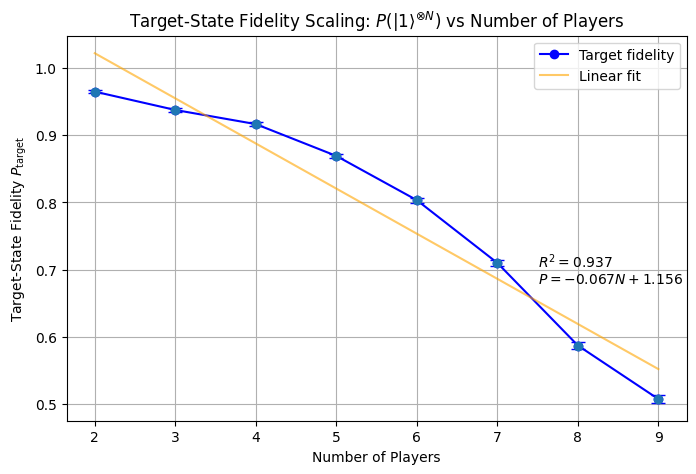

In [18]:
# 1. Linear Regression Modeling
model = LinearRegression()
model.fit(np.array(players).reshape(-1, 1), np.array(mean_fidelity))
intercep = model.intercept_
coef = model.coef_[0]
R2 = model.score(np.array(players).reshape(-1, 1), np.array(mean_fidelity))

# 2. Trend Visualization
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.errorbar(players, mean_fidelity, yerr=ic95_fidelity, fmt='o', ecolor="blue", capsize=5)
ax1.plot(players, mean_fidelity, marker='o', color="blue", label='Target fidelity')
ax1.plot(players, (coef*np.array(players)+intercep), alpha=0.6, color="orange", label='Linear fit')
ax1.text(7.5, 0.68, f'$R^2 = {R2:.3f}$\n$P = {coef:.3f}N + {intercep:.3f}$')
ax1.set_title(r'Target-State Fidelity Scaling: $P(|1\rangle^{\otimes N})$ vs Number of Players')
ax1.set_xlabel('Number of Players')
ax1.set_ylabel(r'Target-State Fidelity $P_{\text{target}}$')
ax1.legend()
ax1.grid()
fig1.show()

fig1.savefig(f'Target_State_Fidelity_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

Fidelity scaling with readout error correction applied. The same linear regression methodology is used; deviations from the next cell reflect the contribution of readout errors to the observed fidelity.

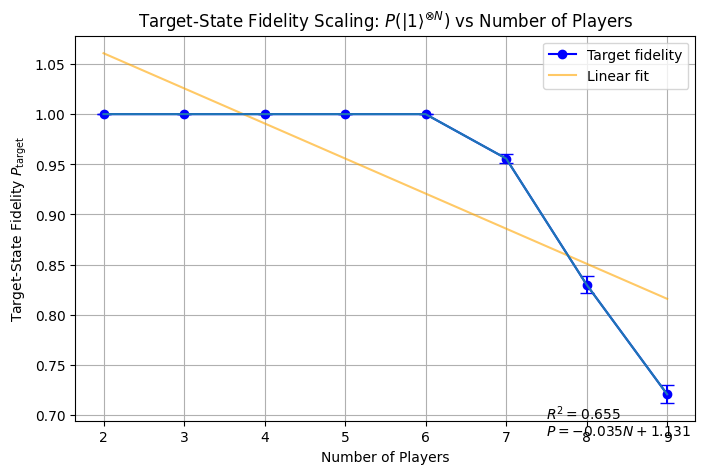

In [19]:
# 1. Linear Regression Modeling
model_mit = LinearRegression()
model_mit.fit(np.array(players).reshape(-1, 1), np.array(mean_fidelity_mit))
intercep_mit = model_mit.intercept_
coef_mit = model_mit.coef_[0]
R2_mit = model_mit.score(np.array(players).reshape(-1, 1), np.array(mean_fidelity_mit))

# 2. Trend Visualization
fig1_mit, ax1_mit = plt.subplots(figsize=(8, 5))
ax1_mit.errorbar(players, mean_fidelity_mit, yerr=ic95_fidelity_mit, ecolor="blue", capsize=5)
ax1_mit.plot(players, mean_fidelity_mit, marker='o', color="blue", label='Target fidelity')
ax1_mit.plot(players, (coef_mit*np.array(players)+intercep_mit), alpha=0.6, color="orange", label='Linear fit')
ax1_mit.text(7.5, 0.68, f'$R^2 = {R2_mit:.3f}$\n$P = {coef_mit:.3f}N + {intercep_mit:.3f}$')
ax1_mit.set_title(r'Target-State Fidelity Scaling: $P(|1\rangle^{\otimes N})$ vs Number of Players')
ax1_mit.set_xlabel('Number of Players')
ax1_mit.set_ylabel(r'Target-State Fidelity $P_{\text{target}}$')
ax1_mit.legend()
ax1_mit.grid()
fig1_mit.show()

fig1_mit.savefig(f'Target_State_Fidelity_mit_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

### **7.2. Target-State Weighted Payoff Contribution**

Weighted payoff contribution of $|1\rangle^{\otimes N}$,  computed as $P(|1\rangle^{\otimes N}) \cdot (b - c/N)$, plotted against the theoretical benchmark. Shown for raw QPU and readout-corrected results.

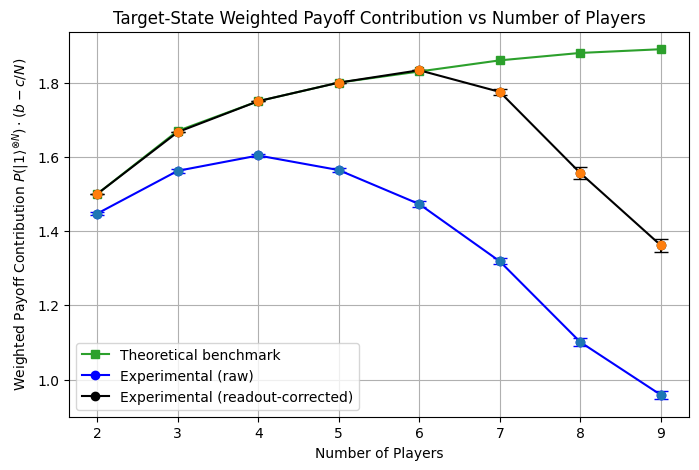

In [20]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.errorbar(players, mean_CPayoff, yerr=ic95_CPayoff, fmt='o', ecolor='blue', capsize=5)
ax2.errorbar(players, mean_CPayoff_mit, yerr=ic95_CPayoff_mit, fmt='o', ecolor='black', capsize=5)
ax2.plot(players, Theorist, marker='s', label='Theoretical benchmark')
ax2.plot(players, mean_CPayoff, marker='o', color='blue', label='Experimental (raw)')
ax2.plot(players, mean_CPayoff_mit, marker='o', color='black', label='Experimental (readout-corrected)')
ax2.set_xlabel('Number of Players')
ax2.set_title(r'Target-State Weighted Payoff Contribution vs Number of Players')
ax2.set_ylabel(r'Weighted Payoff Contribution $P(|1\rangle^{\otimes N}) \cdot (b - c/N)$')
ax2.legend()
ax2.grid()
fig2.show()

fig2.savefig(f'Conditional_Payoff_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

### **7.3. Noise Characterization via Undesired State Probability**

This subsection quantifies background noise by measuring the average probability of obtaining outcomes outside the target state. This metric provides a first-order estimate of error magnitude across different system sizes.

Average probability of non-target states per repetition, for each N, with and without readout correction.

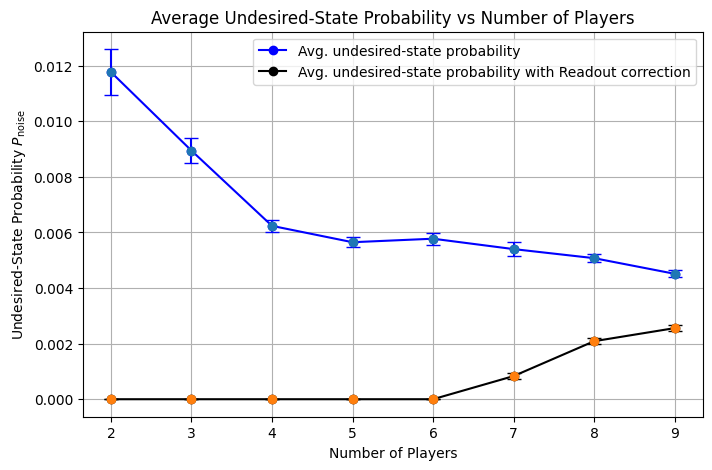

In [21]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.errorbar(players, mean_noise, yerr=ic95_noise, fmt="o", ecolor="blue", capsize=5)
ax3.errorbar(players, mean_noise_mit, yerr=ic95_noise_mit, fmt="o", ecolor="black", capsize=5)
ax3.plot(players, mean_noise, marker='o', color="blue", label='Avg. undesired-state probability')
ax3.plot(players, mean_noise_mit, marker='o', color="black", label='Avg. undesired-state probability with Readout correction')
ax3.set_title('Average Undesired-State Probability vs Number of Players')
ax3.set_xlabel('Number of Players')
ax3.set_ylabel(r'Undesired-State Probability $P_{\text{noise}}$')
ax3.legend()
ax3.grid()
fig3.show()

fig3.savefig(f'Average_Undesired_State_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

**7.3.1. Hamming Distance Distribution of Undesired States**

This subsection analyzes the structure of noise-induced errors by computing the probability distribution over undesired states grouped by Hamming distance from the target state $|1\rangle^{\otimes N}$.

A non-uniform distribution, with states at distance 1 concentrating significantly more probability than states at larger distances, indicates that single-qubit errors dominate over correlated multi-qubit errors. This provides empirical support for the first-order noise model used in the Digital Twin construction.


Hamming Distance Breakdown (probability by distance from target)
────────────────────────────────────────────────────────────
   N |   d=0 |   d=1 |   d=2 |   d=3 |   d=4 |   d=5 |   d=6 |   d=7 |   d=8 |   d=9
────────────────────────────────────────────────────────────
   2 | 0.9647 | 0.0328 | 0.0025
   3 | 0.9374 | 0.0462 | 0.0130 | 0.0034
   4 | 0.9164 | 0.0521 | 0.0096 | 0.0172 | 0.0046
   5 | 0.8691 | 0.0689 | 0.0098 | 0.0107 | 0.0307 | 0.0108
   6 | 0.8033 | 0.0937 | 0.0131 | 0.0100 | 0.0131 | 0.0385 | 0.0285
   7 | 0.7099 | 0.1104 | 0.0190 | 0.0098 | 0.0102 | 0.0219 | 0.0928 | 0.0259
   8 | 0.5871 | 0.1148 | 0.0801 | 0.0170 | 0.0107 | 0.0232 | 0.0817 | 0.0631 | 0.0222
   9 | 0.5075 | 0.1267 | 0.0385 | 0.0748 | 0.0188 | 0.0182 | 0.0266 | 0.0268 | 0.0576 | 0.1045


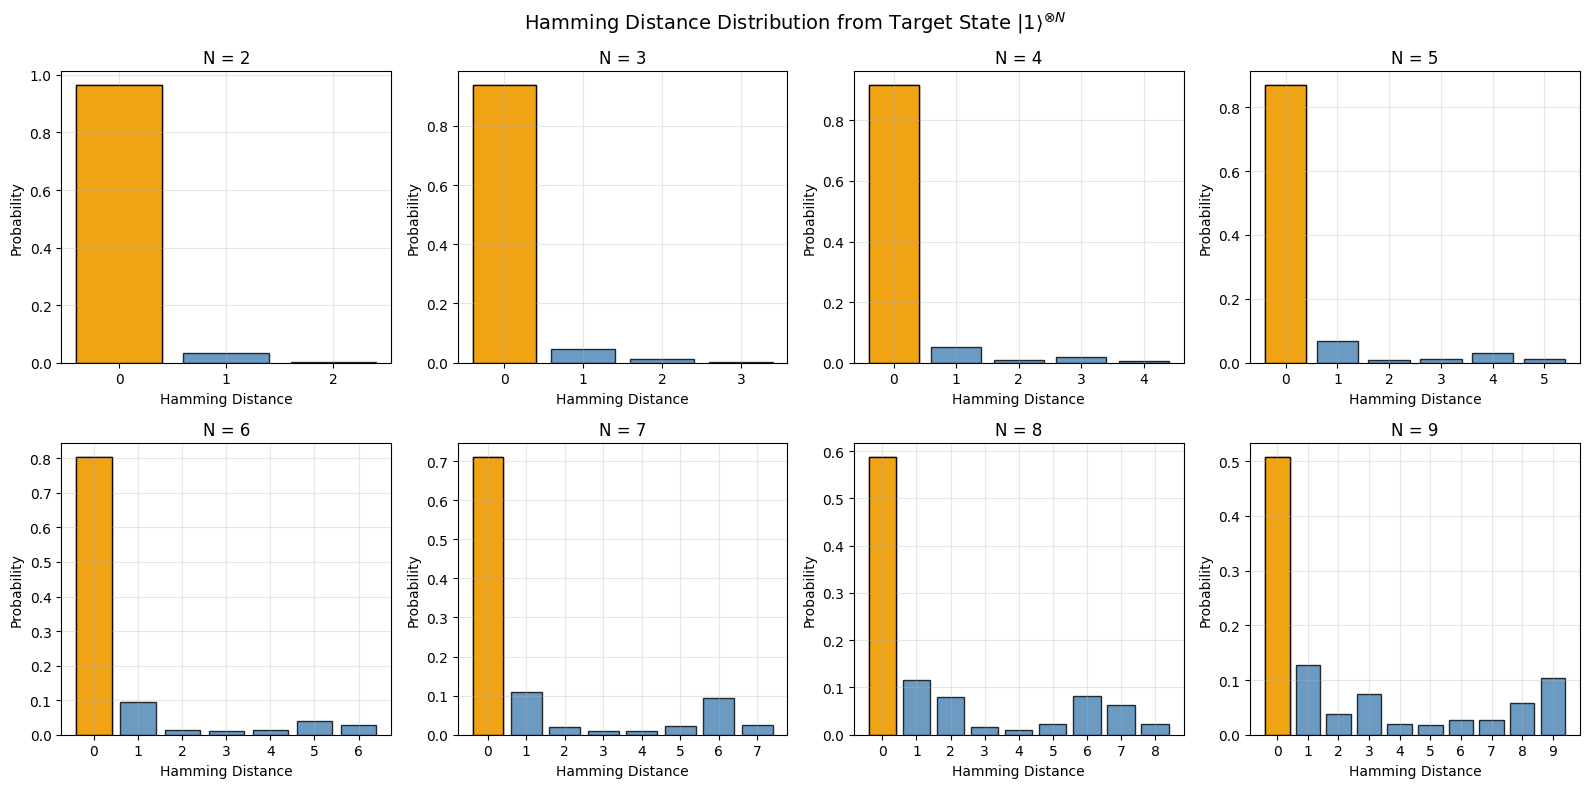

In [22]:
# ── Hamming Distance Analysis ──────────────────────────────────────────────

fig_ham, axes_ham = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes_ham = axes_ham.flatten()

for idx, N in enumerate(range(2, T_Players + 1)):
    target = '1' * N
    counts = aggregated_counts[N]

    # Group probability by Hamming distance from target
    hamming_dist = defaultdict(float)
    total = sum(counts.values())

    for bitstring, count in counts.items():
        # Qiskit little-endian: reverse bitstring to align with player mapping
        bs = bitstring[::-1]
        # Pad or trim to N bits if needed
        bs = bs.zfill(N)[-N:]
        d = sum(b1 != b2 for b1, b2 in zip(bs, target))
        hamming_dist[d] += count / total

    distances = sorted(hamming_dist.keys())
    probs = [hamming_dist[d] for d in distances]

    axes_ham[idx].bar(distances, probs, color='steelblue', edgecolor='black', alpha=0.8)
    axes_ham[idx].set_title(f'N = {N}')
    axes_ham[idx].set_xlabel('Hamming Distance')
    axes_ham[idx].set_ylabel('Probability')
    axes_ham[idx].set_xticks(distances)
    axes_ham[idx].grid(True, alpha=0.3)

    # Annotate target state bar (distance 0)
    if 0 in hamming_dist:
        axes_ham[idx].bar([0], [hamming_dist[0]], color='orange',
                          edgecolor='black', alpha=0.9, label=f'Target')

fig_ham.suptitle(
    r'Hamming Distance Distribution from Target State $|1\rangle^{\otimes N}$',
    fontsize=14
)
plt.tight_layout()
fig_ham.savefig(f'Hamming_Distance_run0{optimization_level + 1}.png',
                dpi=300, bbox_inches='tight')
fig_ham.show()

# --- Numerical summary ---
print("\nHamming Distance Breakdown (probability by distance from target)")
print("─" * 60)
print(f"{'N':>4} | " + " | ".join([f"  d={d}" for d in range(10)]))
print("─" * 60)
for N in range(2, T_Players + 1):
    target = '1' * N
    counts = aggregated_counts[N]
    total = sum(counts.values())
    hamming_dist = defaultdict(float)
    for bitstring, count in counts.items():
        bs = bitstring[::-1].zfill(N)[-N:]
        d = sum(b1 != b2 for b1, b2 in zip(bs, target))
        hamming_dist[d] += count / total
    row = f"{N:>4} | " + " | ".join(
        [f"{hamming_dist.get(d, 0):.4f}" for d in range(N + 1)]
    )
    print(row)

### **7.4. Payoff Comparison: Quantum, Classical, and Experimental Results**

Global average payoff with 95% t-Student confidence intervals, compared against the quantum theoretical benchmark and the classical Nash equilibrium.

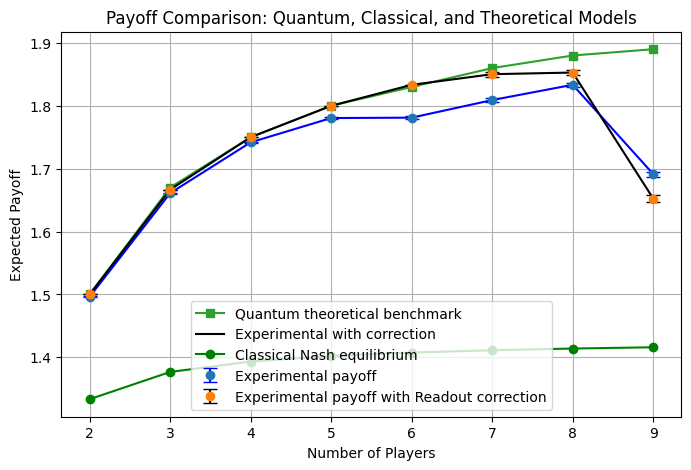

In [23]:
fig4, ax4 = plt.subplots(figsize=(8, 5))
ax4.errorbar(players, mean_val, yerr=ic95_val, fmt='o', ecolor='blue', capsize=5, label='Experimental payoff')
ax4.errorbar(players, mean_val_mit, yerr=ic95_val_mit, fmt='o', ecolor='black', capsize=5, label='Experimental payoff with Readout correction')
ax4.plot(players, Theorist, marker='s', label='Quantum theoretical benchmark')
ax4.plot(players, mean_val, color='blue')
ax4.plot(players, mean_val_mit, color='black', label="Experimental with correction")
ax4.plot(players, Classical, color="green", marker='o', label="Classical Nash equilibrium")
ax4.set_title('Payoff Comparison: Quantum, Classical, and Theoretical Models')
ax4.set_xlabel('Number of Players')
ax4.set_ylabel('Expected Payoff')
ax4.legend()
ax4.grid()
fig4.show()

fig4.savefig(f'Payoff_Comparison_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

### **7.5. Relative Dispersion Analysis via Coefficient of Variation (CV)**

CV = (σ/μ) × 100 computed for global average payoff and undesired-state probability, for raw and corrected results across all N.

In [24]:
print("\nPAYOFF COEFFICIENT OF VARIATION (%)")
print("-" * 40)

for i, val_cv in enumerate(cv_mean):
    print(f"N = {i+2}: {val_cv:.4f}%")

print(f"\nAverage Payoff CV: {np.mean(cv_mean):.4f}%")

print("\nPAYOFF COEFFICIENT OF VARIATION Mit (%)")
print("-" * 40)

for i, val_cv in enumerate(cv_mean_mit):
    print(f"N = {i+2}: {val_cv:.4f}%")

print(f"\nAverage Payoff Mit CV: {np.mean(cv_mean_mit):.4f}%")

print("\n\nNOISE COEFFICIENT OF VARIATION (%)")
print("-" * 40)

for i, err_cv in enumerate(cv_err_mean):
    print(f"N = {i+2}: {err_cv:.4f}%")

print(f"\nAverage Noise CV: {np.mean(cv_err_mean):.4f}%")

print("\n\nNOISE COEFFICIENT OF VARIATION Mit (%)")
print("-" * 40)

for i, err_cv in enumerate(cv_err_mean_mit):
    print(f"N = {i+2}: {err_cv:.4f}%")

print(f"\nAverage Noise Mit CV: {np.mean(cv_err_mean_mit):.4f}%")


PAYOFF COEFFICIENT OF VARIATION (%)
----------------------------------------
N = 2: 0.1115%
N = 3: 0.1145%
N = 4: 0.1153%
N = 5: 0.2420%
N = 6: 0.2904%
N = 7: 0.3062%
N = 8: 0.3893%
N = 9: 0.4906%

Average Payoff CV: 0.2575%

PAYOFF COEFFICIENT OF VARIATION Mit (%)
----------------------------------------
N = 2: 0.0000%
N = 3: 0.0000%
N = 4: 0.0000%
N = 5: 0.0000%
N = 6: 0.0000%
N = 7: 0.4591%
N = 8: 0.5339%
N = 9: 0.7514%

Average Payoff Mit CV: 0.2181%


NOISE COEFFICIENT OF VARIATION (%)
----------------------------------------
N = 2: 14.9312%
N = 3: 10.8752%
N = 4: 7.5174%
N = 5: 7.1506%
N = 6: 7.9650%
N = 7: 10.0379%
N = 8: 6.1853%
N = 9: 6.0485%

Average Noise CV: 8.8389%


NOISE COEFFICIENT OF VARIATION Mit (%)
----------------------------------------
N = 2: nan%
N = 3: nan%
N = 4: nan%
N = 5: nan%
N = 6: nan%
N = 7: 29.9268%
N = 8: 10.7578%
N = 9: 8.3118%

Average Noise Mit CV: nan%


### **7.6. Digital Twin: Success Probability Scaling**

Linear regression fit of Digital Twin target-state fidelity vs. number of players. The simulation is run 20 times with independent seeds, matching the QPU repetition count to enable direct statistical comparison (KS test in Section 7.7.1) and to assess model stability under stochastic variation.

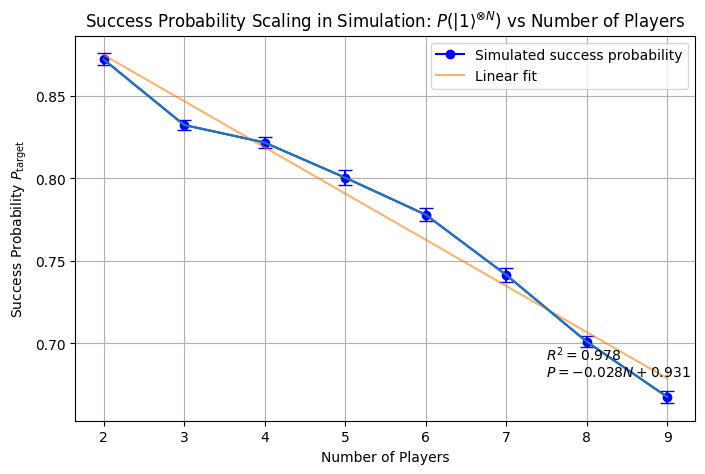

In [25]:
# 1. Linear Regression
model_s = LinearRegression()
model_s.fit(np.array(players).reshape(-1, 1), np.array(mean_sim_fidelity))
intercep_s = model_s.intercept_
coef_s = model_s.coef_[0]
R2_s = model_s.score(np.array(players).reshape(-1, 1), np.array(mean_sim_fidelity))

# 2. Trend Visualization
fig5, ax5 = plt.subplots(figsize=(8, 5))
ax5.errorbar(players, mean_sim_fidelity, yerr=ic95_sim_fidelity, ecolor='blue', capsize=5)
ax5.plot(players, mean_sim_fidelity, marker='o', color="blue", label='Simulated success probability')
ax5.plot(players, (coef_s*np.array(players)+intercep_s), alpha=0.6, label='Linear fit')
ax5.text(7.5, 0.68, f'$R^2 = {R2_s:.3f}$\n$P = {coef_s:.3f}N + {intercep_s:.3f}$')
ax5.set_title(r'Success Probability Scaling in Simulation: $P(|1\rangle^{\otimes N})$ vs Number of Players')
ax5.set_xlabel('Number of Players')
ax5.set_ylabel(r'Success Probability $P_{\text{target}}$')
ax5.legend()
ax5.grid()
fig5.show()

fig5.savefig(f'Success_Probability_Simulation_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

### **7.7. Digital Twin Validation via QPU–Simulation Agreement**

This subsection compares the outcomes obtained from physical hardware execution (QPU) with those generated by the noisy simulation (Digital Twin) to assess the agreement between both models.

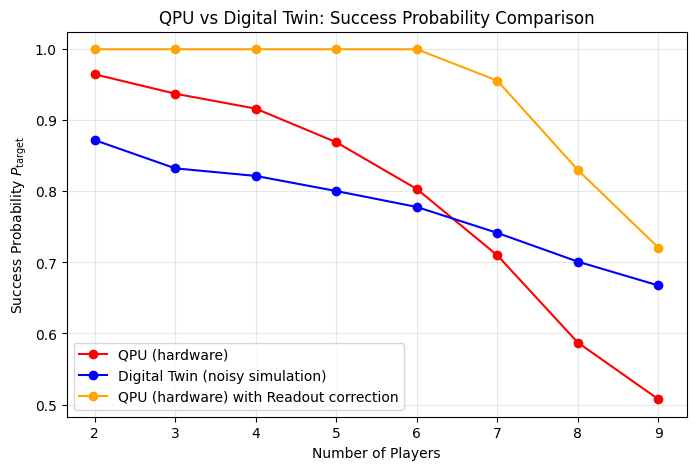

In [26]:
fig6, ax6 = plt.subplots(figsize=(8, 5))
ax6.plot(players, mean_fidelity, marker='o', color='red', label='QPU (hardware)')
ax6.plot(players, mean_sim_fidelity, marker='o', color='blue', label='Digital Twin (noisy simulation)')
ax6.plot(players, mean_fidelity_mit, marker='o', color='orange', label='QPU (hardware) with Readout correction')
ax6.set_title('QPU vs Digital Twin: Success Probability Comparison')
ax6.set_xlabel('Number of Players')
ax6.set_ylabel(r'Success Probability $P_{\text{target}}$')
ax6.legend()
ax6.grid(True, alpha=0.3)
fig6.show()

fig6.savefig(f'QPU_vs_Digital_Twin_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

**7.7.1. Formal Statistical Validation of the Digital Twin**

The Kolmogorov-Smirnov (KS) test is applied to formally assess whether the payoff distributions generated by the Digital Twin are statistically consistent with the QPU hardware results across all player counts.

A p-value above 0.05 indicates that the null hypothesis (both distributions drawn from the same underlying distribution) cannot be rejected at the 5% significance level.

In [27]:
# ── KS Test: Digital Twin vs QPU ──────────────────────────────────────────

print("Kolmogorov–Smirnov Test: Digital Twin vs QPU Payoffs")
print("─" * 60)
print(f"{'N':>4} | {'KS stat':>10} | {'p-value':>12} | {'Consistent?':>12}")
print("─" * 60)

for i, N in enumerate(range(2, T_Players + 1)):
    stat, pval = Validation_DT[i]
    consistent = "✅ Yes" if pval > 0.05 else "❌ No"
    print(f"{N:>4} | {stat:>10.4f} | {pval:>12.4f} | {consistent:>12}")

print("─" * 60)
print("\nWith Readout Correction:")
print("─" * 60)
print(f"{'N':>4} | {'KS stat':>10} | {'p-value':>12} | {'Consistent?':>12}")
print("─" * 60)

for i, N in enumerate(range(2, T_Players + 1)):
    stat, pval = Validation_DT_mit[i]
    consistent = "✅ Yes" if pval > 0.05 else "❌ No"
    print(f"{N:>4} | {stat:>10.4f} | {pval:>12.4f} | {consistent:>12}")

Kolmogorov–Smirnov Test: Digital Twin vs QPU Payoffs
────────────────────────────────────────────────────────────
   N |    KS stat |      p-value |  Consistent?
────────────────────────────────────────────────────────────
   2 |     0.8000 |       0.0000 |         ❌ No
   3 |     0.1500 |       0.9831 |        ✅ Yes
   4 |     0.4000 |       0.0811 |        ✅ Yes
   5 |     0.7500 |       0.0000 |         ❌ No
   6 |     1.0000 |       0.0000 |         ❌ No
   7 |     1.0000 |       0.0000 |         ❌ No
   8 |     0.6500 |       0.0003 |         ❌ No
   9 |     1.0000 |       0.0000 |         ❌ No
────────────────────────────────────────────────────────────

With Readout Correction:
────────────────────────────────────────────────────────────
   N |    KS stat |      p-value |  Consistent?
────────────────────────────────────────────────────────────
   2 |     1.0000 |       0.0000 |         ❌ No
   3 |     1.0000 |       0.0000 |         ❌ No
   4 |     1.0000 |       0.0000 |      

### **7.8. Payoff Benchmark Across Theoretical, Simulated, and Experimental Models**

This subsection compares the economic performance across theoretical, simulated, and experimental regimes by overlaying the corresponding payoff profiles.

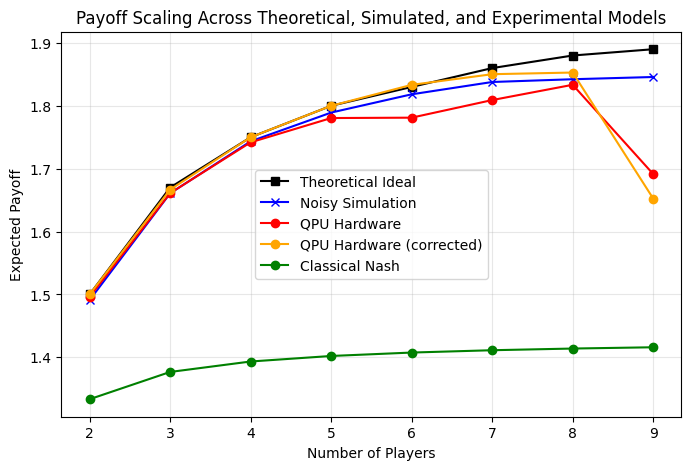

In [28]:
fig7, ax7 = plt.subplots(figsize=(8, 5))
ax7.plot(players, Theorist, marker='s', color='black', label='Theoretical Ideal')
ax7.plot(players, mean_sim_val, marker='x', color='blue', label='Noisy Simulation')
ax7.plot(players, mean_val, marker='o', color='red', label='QPU Hardware')
ax7.plot(players, mean_val_mit, marker='o', color='orange', label='QPU Hardware (corrected)')
ax7.plot(players, Classical, color="green", marker='o', label="Classical Nash")
ax7.set_title('Payoff Scaling Across Theoretical, Simulated, and Experimental Models')
ax7.set_xlabel('Number of Players')
ax7.set_ylabel('Expected Payoff')
ax7.legend()
ax7.grid(True, alpha=0.3)
fig7.show()

fig7.savefig(f'Payoff_Scaling_run0{optimization_level + 1}.png', dpi=300, bbox_inches='tight')

### **7.9. Benchmark Error Metrics: QPU and Digital Twin vs Theoretical Prediction**

AE, and RE computed for QPU (raw), QPU (readout-corrected), and Digital Twin payoffs relative to the theoretical benchmark, across $N = 2, \ldots, 9$.

In [29]:
# AE: |QPU - theoretical| for each N
mae = np.abs(np.array(mean_val) - np.array(Theorist))
mae_mit = np.abs(np.array(mean_val_mit) - np.array(Theorist))
mae_s = np.abs(np.array(mean_sim_val) - np.array(Theorist))

# RE: |QPU - theoretical| / theoretical × 100
mre = np.abs((np.array(mean_val) - np.array(Theorist)) / np.array(Theorist)) * 100
mre_mit = np.abs((np.array(mean_val_mit) - np.array(Theorist)) / np.array(Theorist)) * 100
mre_s = np.abs((np.array(mean_sim_val) - np.array(Theorist)) / np.array(Theorist)) * 100

print("─" * 45)
print("  QPU vs Theoretical Benchmark")
print("─" * 45)
print(f"  AE  (Absolute Error):")
for i, N in enumerate(range(2, T_Players + 1)):
    print(f"{N:>4} | {mae[i]:>12.4f}")
print(f"  RE  (Relative Error):")
for i, N in enumerate(range(2, T_Players + 1)):
    print(f"{N:>4} | {mre[i]:>12.4f}%")
print("─" * 45)
print("  QPU with readout correction vs Theoretical Benchmark")
print("─" * 45)
print(f"  AE  (Absolute Error):")
for i, N in enumerate(range(2, T_Players + 1)):
    print(f"{N:>4} | {mae_mit[i]:>12.4f}")
print(f"  RE  (Relative Error):")
for i, N in enumerate(range(2, T_Players + 1)):
    print(f"{N:>4} | {mre_mit[i]:>12.4f}%")
print("─" * 45)
print("  Simulation vs Theoretical Benchmark")
print("─" * 45)
print(f"  AE  (Absolute Error):")
for i, N in enumerate(range(2, T_Players + 1)):
    print(f"{N:>4} | {mae_s[i]:>12.4f}")
print(f"  RE  (Relative Error):")
for i, N in enumerate(range(2, T_Players + 1)):
    print(f"{N:>4} | {mre_s[i]:>12.4f}%")

# ── Readout Correction Offset ──────────────────────────────────────────────
print("─" * 45)
print("  Readout Correction Impact")
print("─" * 45)
print(f"{'N':>4} | {'Abs. offset':>12} | {'Rel. offset (%)':>16}")
print("─" * 45)

for i, N in enumerate(range(2, T_Players + 1)):
    abs_offset = np.mean(np.array(val_mit[i]) - np.array(val[i]))
    rel_offset = abs_offset / np.mean(val[i]) * 100
    print(f"{N:>4} | {abs_offset:>12.4f} | {rel_offset:>15.2f}%")

total_offset = np.mean([
    abs(np.mean(np.array(val[i]) - np.array(val_mit[i])) / np.mean(val[i]))
    for i in range(T_Players - 1)
]) * 100

print("─" * 45)
print(f"  Mean relative offset: {total_offset:.2f}%")

─────────────────────────────────────────────
  QPU vs Theoretical Benchmark
─────────────────────────────────────────────
  AE  (Absolute Error):
   2 |       0.0038
   3 |       0.0089
   4 |       0.0081
   5 |       0.0195
   6 |       0.0489
   7 |       0.0509
   8 |       0.0466
   9 |       0.1986
  RE  (Relative Error):
   2 |       0.2515%
   3 |       0.5358%
   4 |       0.4639%
   5 |       1.0815%
   6 |       2.6697%
   7 |       2.7351%
   8 |       2.4769%
   9 |      10.5067%
─────────────────────────────────────────────
  QPU with readout correction vs Theoretical Benchmark
─────────────────────────────────────────────
  AE  (Absolute Error):
   2 |       0.0000
   3 |       0.0033
   4 |       0.0000
   5 |       0.0000
   6 |       0.0033
   7 |       0.0097
   8 |       0.0271
   9 |       0.2375
  RE  (Relative Error):
   2 |       0.0000%
   3 |       0.1996%
   4 |       0.0000%
   5 |       0.0000%
   6 |       0.1822%
   7 |       0.5223%
   8 |       1.4407%

### **7.10. Gate Count Analysis and Correlation with Fidelity Decay**

This subsection extracts the gate composition of the transpiled circuits for each optimization level and system size, and analyzes whether the number of two-qubit gates (ECR) correlates with the observed fidelity decay slopes.

ECR gate count and circuit depth extracted from transpiled circuits for each optimization level (0-3) and player count (N = 2-9).

In [30]:
# ── Gate Count Analysis ────────────────────────────────────────────────────

gate_count_table = {}

print("Gate counts per optimization level and N")
print("─" * 70)
print(f"{'N':>4} | " + " | ".join([f"L{l} ECR  L{l} depth" for l in range(4)]))
print("─" * 70)

for N in range(2, T_Players + 1):
    gate_count_table[N] = {}
    row = f"{N:>4} | "
    qc_base = QuantumVolunteersdilemma_Real(N).Build(0, np.pi/N)
    layout = list(range(N))

    for level in range(4):
        try:
            pm = generate_preset_pass_manager(
                backend=backend,
                optimization_level=level,
                initial_layout=layout
            )
            tc = pm.run(qc_base)
            ops = tc.count_ops()
            ecr = ops.get('ecr', ops.get('cz', 0))
            depth = tc.depth()
            gate_count_table[N][level] = {'ecr': ecr, 'depth': depth, 'ops': ops}
            row += f"{ecr:>6}  {depth:>7}   "
        except Exception as e:
            gate_count_table[N][level] = {'ecr': None, 'depth': None}
            row += f"{'N/A':>6}  {'N/A':>7}   "
    print(row)

# ── Correlation: ECR count vs fidelity decay slope ────────────────────────

# Collect ECR counts for N=9 (largest circuit, most representative)
ecr_by_level = []
valid_levels = []
for level in range(4):
    ecr = gate_count_table[T_Players][level]['ecr']
    if ecr is not None:
        ecr_by_level.append(ecr)
        valid_levels.append(level)

# Slope for the current optimization level only.
# Full Pearson correlation requires processing all 4 jobs and is enabled below.
print(f"\nOptimization level {optimization_level} — N=9:")
print(f"  ECR gates : {gate_count_table[T_Players][optimization_level]['ecr']}")
print(f"  Circuit depth: {gate_count_table[T_Players][optimization_level]['depth']}")
print(f"  Fidelity decay slope: {coef:.4f}")

# ── Pearson correlation (available once all slopes are collected) ──────────
# Uncomment and populate once results from all 4 levels are processed:
#
# slopes_all_levels = [slope_L0, slope_L1, slope_L2, slope_L3]
# ecr_N9 = [gate_count_table[T_Players][l]['ecr'] for l in range(4)]
# r, p = pearsonr(ecr_N9, slopes_all_levels)
# print(f"\nPearson r (ECR vs slope): {r:.4f}, p-value: {p:.4f}")

Gate counts per optimization level and N
──────────────────────────────────────────────────────────────────────
   N | L0 ECR  L0 depth | L1 ECR  L1 depth | L2 ECR  L2 depth | L3 ECR  L3 depth
──────────────────────────────────────────────────────────────────────
   2 |      4       55        4       28        2       14        2       14   
   3 |      8       71        8       48        6       36        6       36   
   4 |     12       87       12       62       10       46       10       46   
   5 |     16      103       16       80       14       60       14       60   
   6 |     20      119       20       96       18       72       18       72   
   7 |     24      135       24      112       22       84       22       84   
   8 |     28      151       28      128       26       96       26       96   
   9 |     32      167       32      144       30      108       30      108   

Optimization level 2 — N=9:
  ECR gates : 30
  Circuit depth: 108
  Fidelity decay slope: -0.06